In [4]:
# -*- coding: utf-8 -*-
"""Data Scientist-TechChallenge.ipynb"""

# ============================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, spearmanr

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import joblib

# Configurações visuais
sns.set_theme(
    style="whitegrid",
    palette="Set2"
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [5]:
# ============================================================
# 2. CARREGANDO OS DADOS
# ============================================================

df = pd.read_csv("/content/desafio_nps_fase_1.csv")

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")

Linhas: 2,500
Colunas: 19


In [6]:
# ============================================================
# 3. VISÃO GERAL
# ============================================================

display(df.head())

# A linha df["nps_class"].value_counts() foi removida daqui,
# pois a coluna só é criada na Seção 7.

df.info()

display(df.describe(include="all").T)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.90,0,3,6.50
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.40,0,3,0.00
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.80,0,7,1.50
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.90,0,4,0.30
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.10,0,3,7.90


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,"2,500.00",NaN,NaN,NaN,"1,250.50",721.83,1.00,625.75,"1,250.50","1,875.25","2,500.00"
customer_age,"2,500.00",NaN,NaN,NaN,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_region,2500,5,Sul,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_tenure_months,"2,500.00",NaN,NaN,NaN,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,"2,500.00",NaN,NaN,NaN,"51,250.50",721.83,"50,001.00","50,625.75","51,250.50","51,875.25","52,500.00"
order_value,"2,500.00",NaN,NaN,NaN,434.26,289.77,7.76,220.25,375.51,577.29,"1,983.81"
items_quantity,"2,500.00",NaN,NaN,NaN,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,"2,500.00",NaN,NaN,NaN,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,"2,500.00",NaN,NaN,NaN,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,"2,500.00",NaN,NaN,NaN,8.02,3.77,2.00,5.00,8.00,11.00,14.00


In [7]:
# ============================================================
# 4. QUALIDADE DOS DADOS
# ============================================================

missing = (
    df.isnull()
      .sum()
      .to_frame("missing_count")
)

missing["missing_pct"] = (
    missing["missing_count"] / len(df) * 100
)

missing = missing.sort_values(
    "missing_pct",
    ascending=False
)

display(missing)

duplicated_rows = df.duplicated().sum()

print(
    f"Quantidade de linhas duplicadas: {duplicated_rows:,}"
)

print(
    f"Clientes únicos: {df['customer_id'].nunique():,}"
)

print(
    f"Pedidos únicos: {df['order_id'].nunique():,}"
)

print(
    f"Linhas da base: {len(df):,}"
)

orders_per_customer = (
    df.groupby("customer_id")["order_id"]
      .nunique()
)

print(
    f"Média de pedidos por cliente: "
    f"{orders_per_customer.mean():.2f}"
)

,missing_count,missing_pct
customer_id,0,0.00
customer_age,0,0.00
customer_region,0,0.00
customer_tenure_months,0,0.00
order_id,0,0.00
order_value,0,0.00
items_quantity,0,0.00
discount_value,0,0.00
payment_installments,0,0.00
delivery_time_days,0,0.00


Quantidade de linhas duplicadas: 0
Clientes únicos: 2,500
Pedidos únicos: 2,500
Linhas da base: 2,500
Média de pedidos por cliente: 1.00


In [8]:
# ============================================================
# 5. VALIDAÇÕES
# ============================================================

print(
    "NPS fora do intervalo 0-10:",
    (~df["nps_score"].between(0, 10)).sum()
)

print(
    "Idades inválidas:",
    (df["customer_age"] <= 0).sum()
)

print(
    "Pedidos com valor negativo:",
    (df["order_value"] < 0).sum()
)

print(
    "Tempo de entrega negativo:",
    (df["delivery_time_days"] < 0).sum()
)

print(
    "Atraso negativo:",
    (df["delivery_delay_days"] < 0).sum()
)

print(
    "Quantidade de itens <= 0:",
    (df["items_quantity"] <= 0).sum()
)

NPS fora do intervalo 0-10: 0
Idades inválidas: 0
Pedidos com valor negativo: 0
Tempo de entrega negativo: 0
Atraso negativo: 0
Quantidade de itens <= 0: 0


In [9]:
# ============================================================
# 6. TRATAMENTO DOS DADOS
# ============================================================

df_clean = df.copy()

# Remover duplicidades exatas
df_clean = df_clean.drop_duplicates()

# Garantir tipos numéricos
numeric_columns = [
    "customer_age",
    "customer_tenure_months",
    "order_value",
    "items_quantity",
    "discount_value",
    "payment_installments",
    "delivery_time_days",
    "delivery_delay_days",
    "freight_value",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",
    "repeat_purchase_30d",
    "csat_internal_score",
    "nps_score"
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )


In [10]:
# ============================================================
# 7. FEATURE ENGINEERING
# ============================================================

# Classificação tradicional do NPS
def classify_nps(score):
    if pd.isna(score):
        return np.nan
    elif score <= 6:
        return "Detrator"
    elif score <= 8:
        return "Neutro"
    else:
        return "Promotor"


df_clean["nps_class"] = (
    df_clean["nps_score"]
    .apply(classify_nps)
)

df_clean["has_delivery_delay"] = (
    df_clean["delivery_delay_days"] > 0
).astype(int)

df_clean["contacted_customer_service"] = (
    df_clean["customer_service_contacts"] > 0
).astype(int)

df_clean["has_complaint"] = (
    df_clean["complaints_count"] > 0
).astype(int)

df_clean["multiple_delivery_attempts"] = (
    df_clean["delivery_attempts"] > 1
).astype(int)

df_clean["delivery_time_group"] = pd.cut(
    df_clean["delivery_time_days"],
    bins=[-np.inf, 2, 5, 10, np.inf],
    labels=[
        "Até 2 dias",
        "3-5 dias",
        "6-10 dias",
        "Mais de 10 dias"
    ]
)

df_clean["age_group"] = pd.cut(
    df_clean["customer_age"],
    bins=[0, 25, 35, 45, 55, np.inf],
    labels=[
        "Até 25",
        "26-35",
        "36-45",
        "46-55",
        "56+"
    ]
)


In [11]:
# ============================================================
# 8. NPS GERAL
# ============================================================

nps_valid = df_clean.dropna(
    subset=["nps_score"]
)

promoters_pct = (
    (nps_valid["nps_score"] >= 9).mean()
)

detractors_pct = (
    (nps_valid["nps_score"] <= 6).mean()
)

nps = (
    promoters_pct - detractors_pct
) * 100

print(f"NPS geral: {nps:.2f}")
print(f"Promotores: {promoters_pct * 100:.2f}%")
print(f"Detratores: {detractors_pct * 100:.2f}%")
print(
    f"Neutros: "
    f"{((nps_valid['nps_score'].between(7, 8)).mean() * 100):.2f}%"
)

NPS geral: -69.64
Promotores: 4.40%
Detratores: 74.04%
Neutros: 7.60%


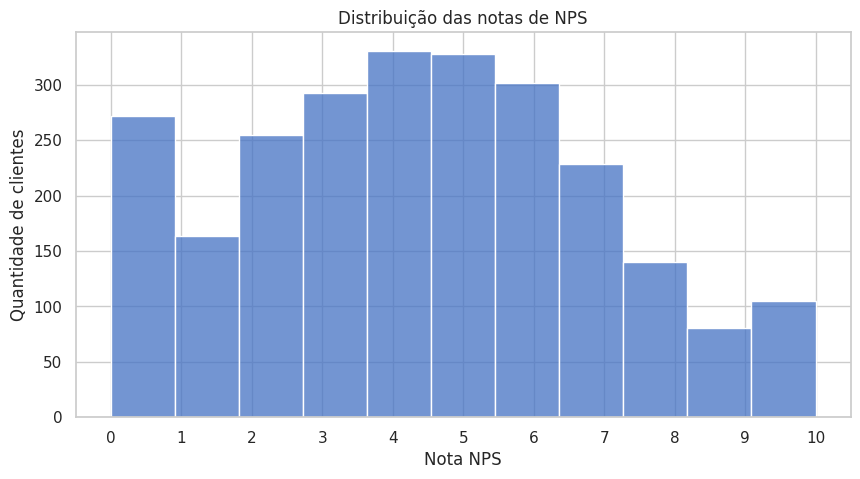

,percentual
nps_class,
Detrator,74.04
Neutro,17.92
Promotor,8.04


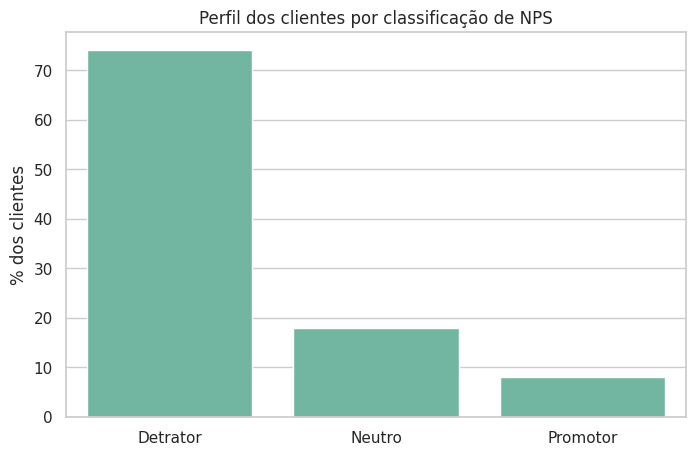

In [14]:
# ============================================================
# 9. DISTRIBUIÇÃO DO NPS (CORRIGIDO)
# ============================================================

plt.figure(figsize=(10, 5))

# Usando histplot para agrupar os números corretamente e não encavalar o eixo X
sns.histplot(
    data=nps_valid,
    x="nps_score",
    bins=11,
    color="#4472C4"
)

plt.title("Distribuição das notas de NPS")
plt.xlabel("Nota NPS")
plt.ylabel("Quantidade de clientes")

# Força o eixo X a exibir apenas inteiros de 0 a 10
plt.xticks(range(0, 11))

plt.show()

nps_distribution = (
    df_clean["nps_class"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex([
        "Detrator",
        "Neutro",
        "Promotor"
    ])
)

display(
    nps_distribution.to_frame(
        "percentual"
    )
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=nps_distribution.index,
    y=nps_distribution.values
)

plt.title("Perfil dos clientes por classificação de NPS")
plt.xlabel("")
plt.ylabel("% dos clientes")

plt.show()


,nps_medio,quantidade
Sem atraso,6.86,277
Com atraso,4.07,2223


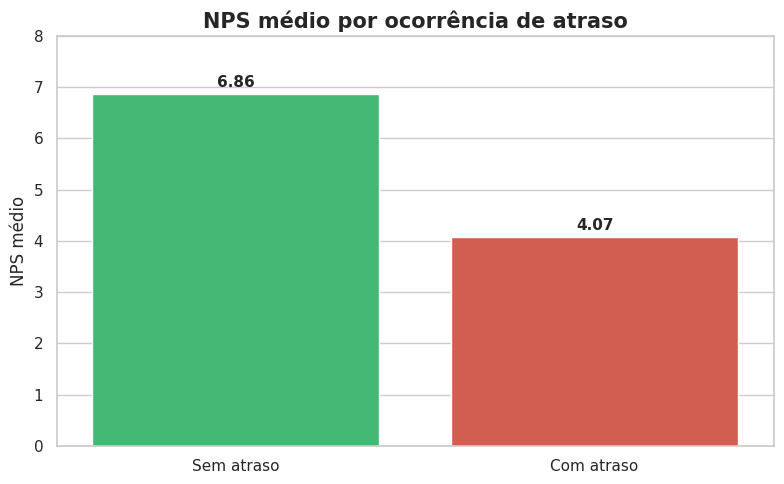

Estatística: 118192.50
p-value: 0.000000
INSIGHT: existe evidência estatística de diferença no NPS entre clientes com e sem atraso.


,delivery_time_group,nps_medio,clientes
0,Até 2 dias,4.34,203
1,3-5 dias,4.31,570
2,6-10 dias,4.49,936
3,Mais de 10 dias,4.31,791


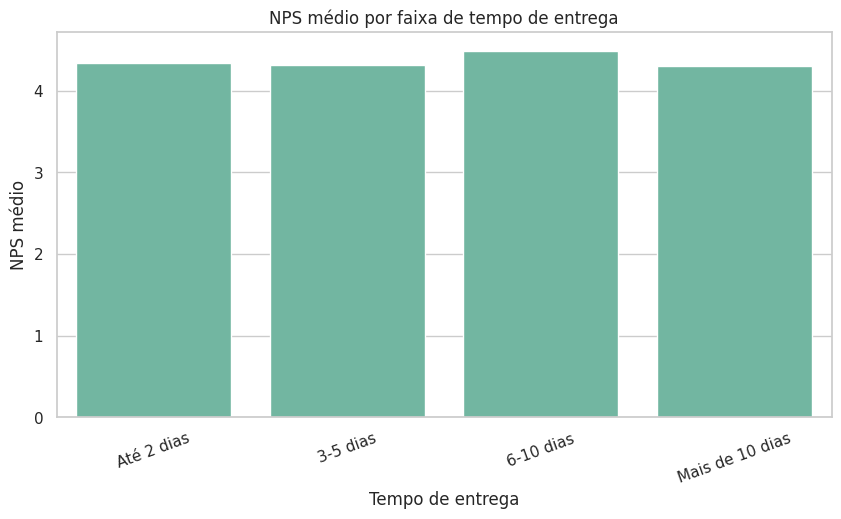

,nps_medio,clientes
Não entrou em contato,5.54,554
Entrou em contato,4.05,1946


,nps_medio,clientes
Sem reclamação,8.52,23
Com reclamação,4.34,2477


Correlação de Spearman: -0.19032955867532628


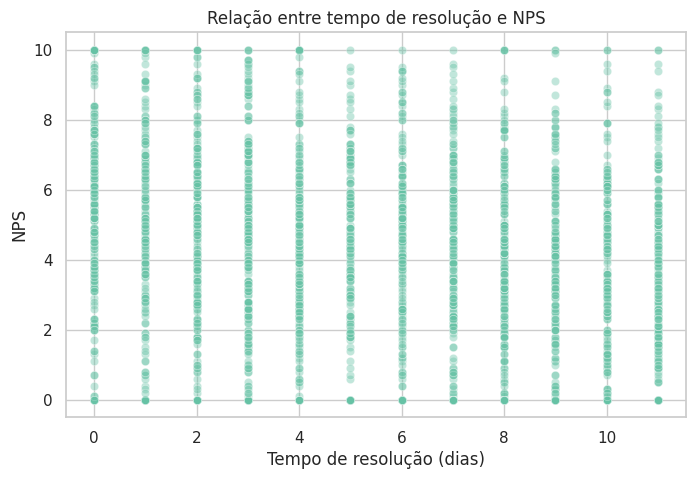

Correlação CSAT x NPS: 0.5608863776633662


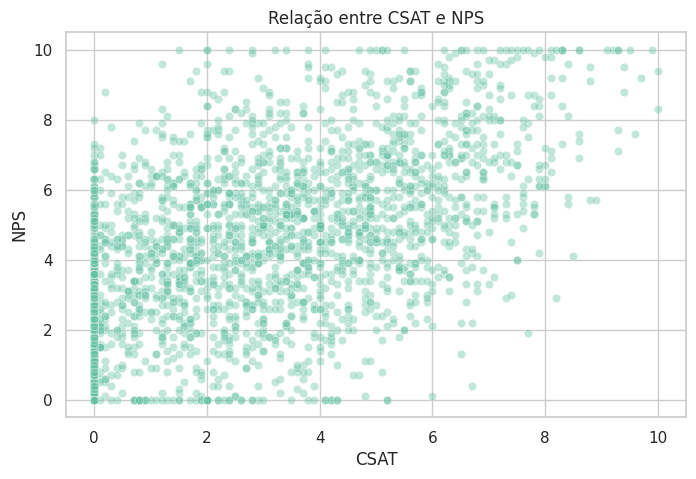

,nps_medio,clientes
customer_region,,
Sul,4.49,521
Nordeste,4.42,485
Norte,4.38,506
Sudeste,4.37,520
Centro-Oeste,4.21,468


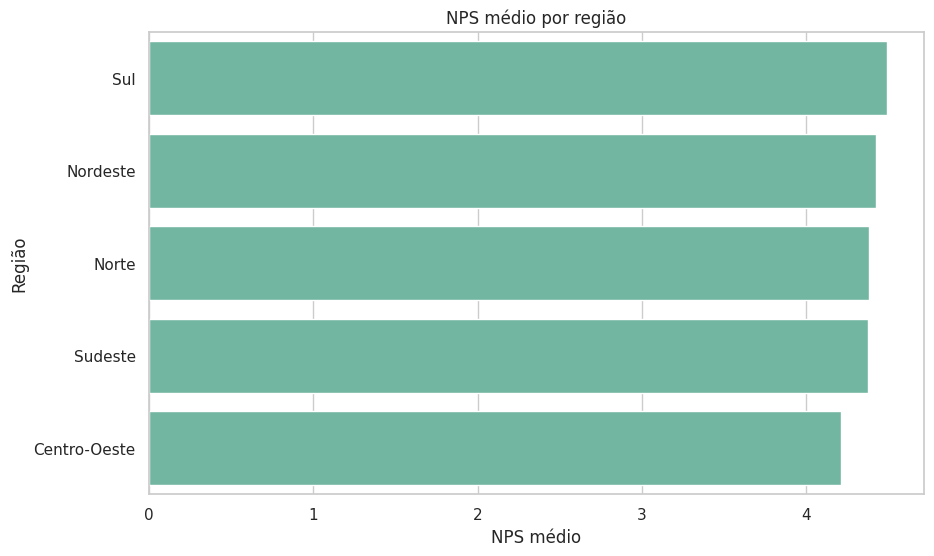

,recompra_30d,clientes,recompra_30d_pct
nps_class,,,
Detrator,0.00,1851,0.00
Neutro,0.04,448,3.79
Promotor,1.00,201,100.00


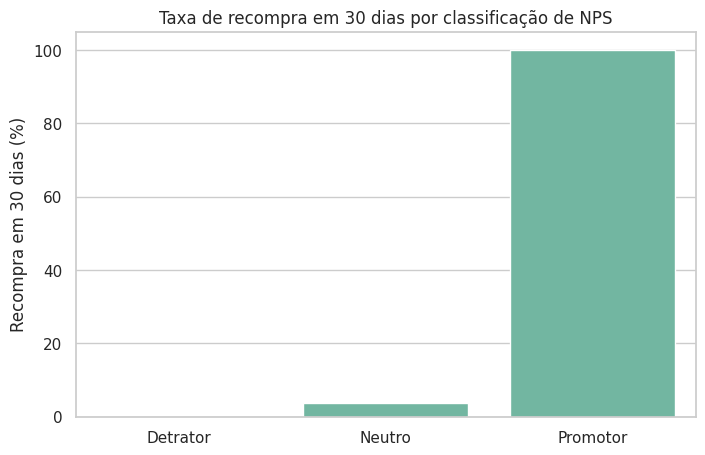

In [13]:
# ============================================================
# 10. NPS x ATRASO
# ============================================================

nps_delay = (
    df_clean
    .groupby("has_delivery_delay")
    .agg(
        nps_medio=("nps_score", "mean"),
        quantidade=("nps_score", "count")
    )
)

nps_delay.index = [
    "Sem atraso",
    "Com atraso"
]

display(nps_delay)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=nps_delay.reset_index(),
    x="index",
    y="nps_medio",
    hue="index",
    palette={
        "Sem atraso": "#2ECC71",
        "Com atraso": "#E74C3C"
    },
    legend=False
)

# Adiciona o valor do NPS em cima das barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "NPS médio por ocorrência de atraso",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("NPS médio")

plt.ylim(0, 8)

plt.tight_layout()
plt.show()

delay_group = df_clean.loc[
    df_clean["has_delivery_delay"] == 1,
    "nps_score"
].dropna()

no_delay_group = df_clean.loc[
    df_clean["has_delivery_delay"] == 0,
    "nps_score"
].dropna()

stat, p_value = mannwhitneyu(
    delay_group,
    no_delay_group,
    alternative="two-sided"
)

print(f"Estatística: {stat:.2f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print(
        "INSIGHT: existe evidência estatística de diferença "
        "no NPS entre clientes com e sem atraso."
    )
else:
    print(
        "INSIGHT: não foi encontrada evidência estatística "
        "suficiente de diferença no NPS entre os grupos."
    )

delivery_analysis = (
    df_clean
    .groupby("delivery_time_group", observed=True)
    .agg(
        nps_medio=("nps_score", "mean"),
        clientes=("nps_score", "count")
    )
    .reset_index()
)

display(delivery_analysis)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=delivery_analysis,
    x="delivery_time_group",
    y="nps_medio"
)

plt.title("NPS médio por faixa de tempo de entrega")
plt.xlabel("Tempo de entrega")
plt.ylabel("NPS médio")

plt.xticks(rotation=20)

plt.show()

service_analysis = (
    df_clean
    .groupby("contacted_customer_service")
    .agg(
        nps_medio=("nps_score", "mean"),
        clientes=("nps_score", "count")
    )
)

service_analysis.index = [
    "Não entrou em contato",
    "Entrou em contato"
]

display(service_analysis)

complaint_analysis = (
    df_clean
    .groupby("has_complaint")
    .agg(
        nps_medio=("nps_score", "mean"),
        clientes=("nps_score", "count")
    )
)

complaint_analysis.index = [
    "Sem reclamação",
    "Com reclamação"
]

display(complaint_analysis)

resolution_corr = df_clean[
    [
        "resolution_time_days",
        "nps_score"
    ]
].corr(
    method="spearman"
)

print(
    "Correlação de Spearman:",
    resolution_corr.loc[
        "resolution_time_days",
        "nps_score"
    ]
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="resolution_time_days",
    y="nps_score",
    alpha=0.4
)

plt.title(
    "Relação entre tempo de resolução e NPS"
)

plt.xlabel("Tempo de resolução (dias)")
plt.ylabel("NPS")

plt.show()

csat_corr = df_clean[
    [
        "csat_internal_score",
        "nps_score"
    ]
].corr(
    method="spearman"
)

print(
    "Correlação CSAT x NPS:",
    csat_corr.loc[
        "csat_internal_score",
        "nps_score"
    ]
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="csat_internal_score",
    y="nps_score",
    alpha=0.4
)

plt.title("Relação entre CSAT e NPS")
plt.xlabel("CSAT")
plt.ylabel("NPS")

plt.show()

region_analysis = (
    df_clean
    .groupby("customer_region")
    .agg(
        nps_medio=("nps_score", "mean"),
        clientes=("nps_score", "count")
    )
    .sort_values(
        "nps_medio",
        ascending=False
    )
)

display(region_analysis)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_analysis.reset_index(),
    x="nps_medio",
    y="customer_region"
)

plt.title("NPS médio por região")
plt.xlabel("NPS médio")
plt.ylabel("Região")

plt.show()

repurchase_analysis = (
    df_clean
    .groupby("nps_class")
    .agg(
        recompra_30d=("repeat_purchase_30d", "mean"),
        clientes=("customer_id", "count")
    )
    .reindex([
        "Detrator",
        "Neutro",
        "Promotor"
    ])
)

repurchase_analysis["recompra_30d_pct"] = (
    repurchase_analysis["recompra_30d"] * 100
)

display(repurchase_analysis)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=repurchase_analysis.reset_index(),
    x="nps_class",
    y="recompra_30d_pct"
)

plt.title(
    "Taxa de recompra em 30 dias por classificação de NPS"
)

plt.xlabel("")
plt.ylabel("Recompra em 30 dias (%)")

plt.show()


nps_class,Detrator,Neutro,Promotor
delivery_time_days,8.00,8.12,8.04
delivery_delay_days,2.53,1.40,0.76
delivery_attempts,1.99,2.04,2.03
customer_service_contacts,1.69,1.13,0.78
resolution_time_days,5.79,4.83,4.10
complaints_count,4.62,2.99,2.39
order_value,428.99,447.33,453.69
customer_tenure_months,61.58,59.51,63.04
csat_internal_score,2.34,4.23,5.60


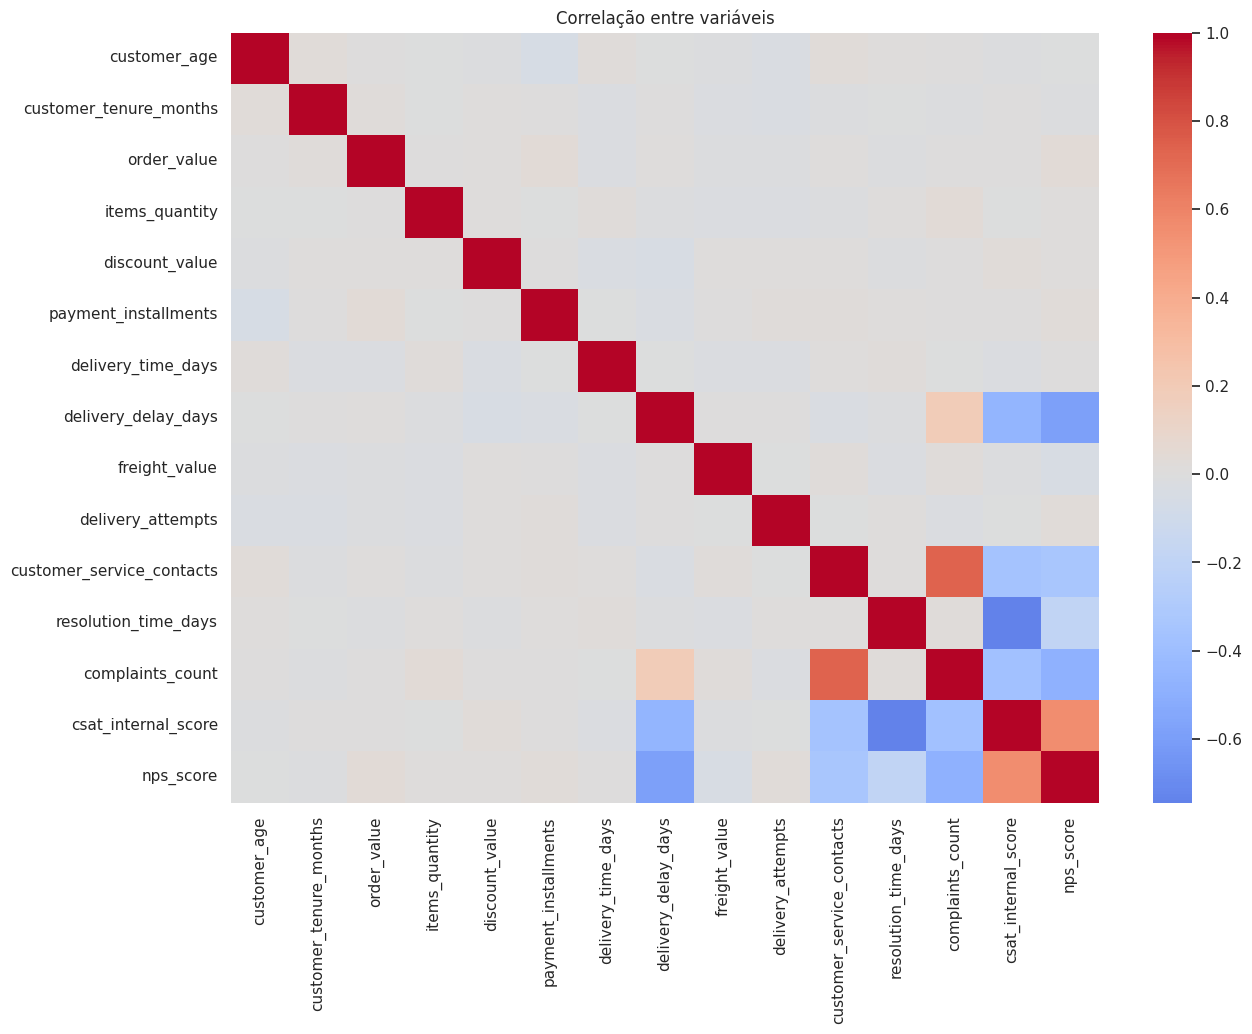

In [15]:
# ============================================================
# 11. COMPARAÇÃO DOS DRIVERS
# ============================================================

driver_columns = [
    "delivery_time_days",
    "delivery_delay_days",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",
    "order_value",
    "customer_tenure_months",
    "csat_internal_score"
]

driver_comparison = (
    df_clean
    .groupby("nps_class")[driver_columns]
    .mean()
    .T
)

driver_comparison = driver_comparison[
    [
        "Detrator",
        "Neutro",
        "Promotor"
    ]
]

display(driver_comparison)

correlation_columns = [
    "customer_age",
    "customer_tenure_months",
    "order_value",
    "items_quantity",
    "discount_value",
    "payment_installments",
    "delivery_time_days",
    "delivery_delay_days",
    "freight_value",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",
    "csat_internal_score",
    "nps_score"
]

correlation_matrix = (
    df_clean[correlation_columns]
    .corr(method="spearman")
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre variáveis")

plt.show()

Treino: (2000, 15)
Teste: (500, 15)
              precision    recall  f1-score   support

           0       0.57      0.78      0.66       130
           1       0.91      0.79      0.85       370

    accuracy                           0.79       500
   macro avg       0.74      0.79      0.75       500
weighted avg       0.82      0.79      0.80       500

ROC-AUC: 0.878
              precision    recall  f1-score   support

           0       0.73      0.55      0.63       130
           1       0.86      0.93      0.89       370

    accuracy                           0.83       500
   macro avg       0.80      0.74      0.76       500
weighted avg       0.82      0.83      0.82       500

ROC-AUC: 0.866


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.79,0.91,0.79,0.85,0.88
1,Random Forest,0.83,0.86,0.93,0.89,0.87


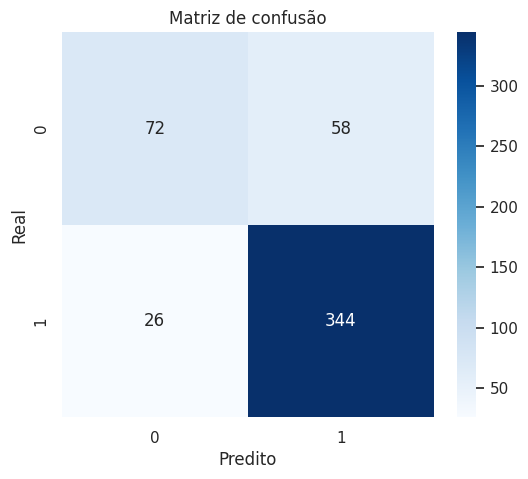

,feature,importance
12,numeric__complaints_count,0.18
13,numeric__csat_internal_score,0.14
7,numeric__delivery_delay_days,0.14
2,numeric__order_value,0.06
4,numeric__discount_value,0.06
8,numeric__freight_value,0.06
1,numeric__customer_tenure_months,0.06
0,numeric__customer_age,0.05
11,numeric__resolution_time_days,0.05
10,numeric__customer_service_contacts,0.04


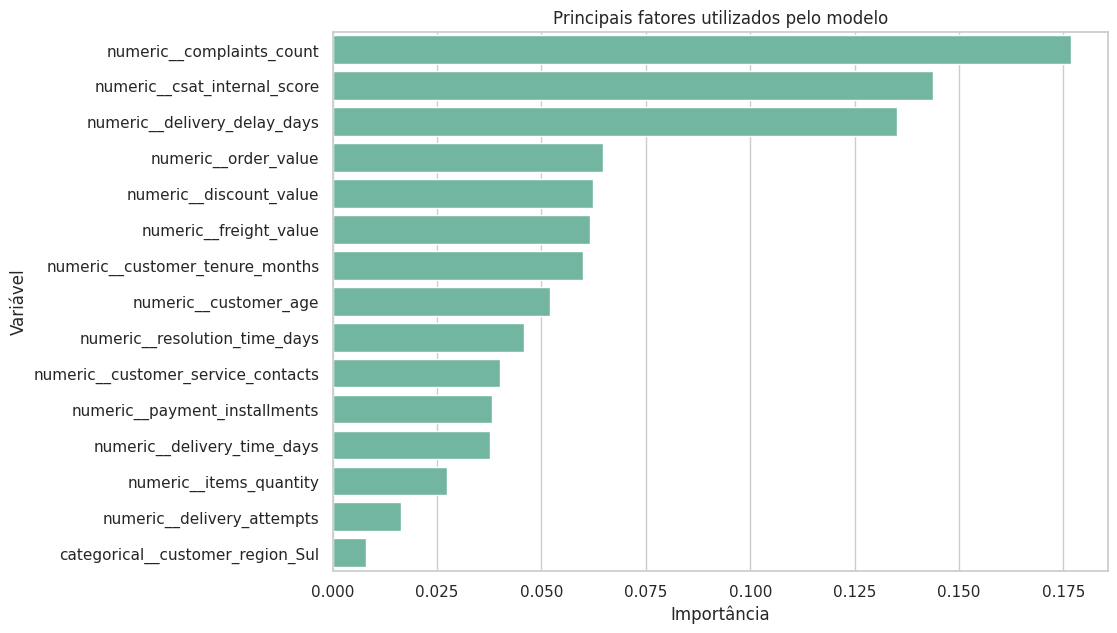

In [16]:
# ============================================================
# 12. MODELO PREDITIVO
# ============================================================

model_df = df_clean.dropna(
    subset=["nps_score"]
).copy()

model_df["is_detractor"] = (
    model_df["nps_score"] <= 6
).astype(int)

features = [
    "customer_age",
    "customer_region",
    "customer_tenure_months",
    "order_value",
    "items_quantity",
    "discount_value",
    "payment_installments",
    "delivery_time_days",
    "delivery_delay_days",
    "freight_value",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",
    "csat_internal_score"
]

target = "is_detractor"

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

categorical_features = [
    "customer_region"
]

numeric_features = [
    col
    for col in features
    if col not in categorical_features
]

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    f"ROC-AUC: "
    f"{roc_auc_score(y_test, y_prob):.3f}"
)

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

y_pred_rf = random_forest_model.predict(
    X_test
)

y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print(
    f"ROC-AUC: "
    f"{roc_auc_score(y_test, y_prob_rf):.3f}"
)

model_comparison = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

display(
    model_comparison.sort_values(
        "ROC_AUC",
        ascending=False
    )
)

best_model = random_forest_model

best_predictions = best_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusão")
plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

rf_pipeline = random_forest_model

preprocessor_fitted = (
    rf_pipeline
    .named_steps["preprocessor"]
)

rf_fitted = (
    rf_pipeline
    .named_steps["model"]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_fitted.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

display(
    feature_importance.head(15)
)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title(
    "Principais fatores utilizados pelo modelo"
)

plt.xlabel("Importância")
plt.ylabel("Variável")

plt.show()


In [17]:
# ============================================================
# 13. RESUMO DOS INSIGHTS
# ============================================================

print("=" * 70)
print("RESUMO DOS PRINCIPAIS INSIGHTS")
print("=" * 70)

print(
    f"\n1. NPS geral: {nps:.1f}"
)

delay_nps_without = nps_delay.loc[
    "Sem atraso",
    "nps_medio"
]

delay_nps_with = nps_delay.loc[
    "Com atraso",
    "nps_medio"
]

difference = (
    delay_nps_without -
    delay_nps_with
)

print(
    f"\n2. Impacto do atraso:"
)

print(
    f"   NPS sem atraso: {delay_nps_without:.2f}"
)

print(
    f"   NPS com atraso: {delay_nps_with:.2f}"
)

print(
    f"   Diferença: {difference:.2f} pontos"
)

promoter_repurchase = (
    repurchase_analysis
    .loc["Promotor", "recompra_30d_pct"]
)

detractor_repurchase = (
    repurchase_analysis
    .loc["Detrator", "recompra_30d_pct"]
)

print(
    f"\n3. Recompra:"
)

print(
    f"   Promotores: {promoter_repurchase:.2f}%"
)

print(
    f"   Detratores: {detractor_repurchase:.2f}%"
)

print(
    f"   Diferença: "
    f"{promoter_repurchase - detractor_repurchase:.2f} p.p."
)

print("\n4. RECOMENDAÇÕES INICIAIS")
print("-" * 50)

if delay_nps_with < delay_nps_without:
    print(
        "• Priorizar redução de atrasos logísticos, "
        "pois clientes com atraso apresentam menor NPS."
    )

if promoter_repurchase > detractor_repurchase:
    print(
        "• Tratar satisfação como indicador estratégico, "
        "pois clientes promotores apresentam maior taxa "
        "de recompra."
    )

if (
    df_clean["has_complaint"].mean() > 0
):
    print(
        "• Monitorar clientes com reclamações e priorizar "
        "resolução rápida dos problemas."
    )


RESUMO DOS PRINCIPAIS INSIGHTS

1. NPS geral: -69.6

2. Impacto do atraso:
   NPS sem atraso: 6.86
   NPS com atraso: 4.07
   Diferença: 2.79 pontos

3. Recompra:
   Promotores: 100.00%
   Detratores: 0.00%
   Diferença: 100.00 p.p.

4. RECOMENDAÇÕES INICIAIS
--------------------------------------------------
• Priorizar redução de atrasos logísticos, pois clientes com atraso apresentam menor NPS.
• Tratar satisfação como indicador estratégico, pois clientes promotores apresentam maior taxa de recompra.
• Monitorar clientes com reclamações e priorizar resolução rápida dos problemas.


In [18]:

# ============================================================
# 14. EXPORTAÇÃO DOS RESULTADOS
# ============================================================

import os

os.makedirs(
    "reports/tables",
    exist_ok=True
)

os.makedirs(
    "reports/figures",
    exist_ok=True
)

driver_comparison.to_csv(
    "reports/tables/nps_drivers.csv"
)

region_analysis.to_csv(
    "reports/tables/nps_by_region.csv"
)

repurchase_analysis.to_csv(
    "reports/tables/nps_repurchase.csv"
)

model_comparison.to_csv(
    "reports/tables/model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "reports/tables/feature_importance.csv",
    index=False
)

os.makedirs(
    "models",
    exist_ok=True
)

joblib.dump(
    random_forest_model,
    "models/nps_detractor_model.pkl"
)

['models/nps_detractor_model.pkl']